In [ ]:
import scanpy as sc # cross celltype predict
import scresid
import pertpy as pt # download dataset
import warnings
warnings.filterwarnings('ignore')
adata = sc.read_h5ad('sc_sim_augur.h5ad') # https://figshare.com/ndownloader/files/49828902
adata

AnnData object with n_obs × n_vars = 600 × 15697
    obs: 'label', 'cell_type'
    var: 'name'

In [ ]:
adata.obs.rename(columns={"label": "condition"}, inplace=True)
adata.obs["condition"].replace({"treatment": "stimulated"}, inplace=True)

In [3]:
adata = sc.AnnData(adata.X, obs=adata.obs.copy(), var=adata.var.copy())
adata.obs_names_make_unique()
print(adata)
print('\n', adata.obs['condition'].value_counts())
print('\n', adata.obs['cell_type'].value_counts())

AnnData object with n_obs × n_vars = 600 × 15697
    obs: 'condition', 'cell_type'
    var: 'name'

 condition
control       306
stimulated    294
Name: count, dtype: int64

 cell_type
CellTypeA    200
CellTypeB    200
CellTypeC    200
Name: count, dtype: int64


In [4]:
model = scresid.SCRESID(input_dim=adata.n_vars, hidden_dim=3000, latent_dim=300, device='cpu')
model = model.to(model.device)
# key_dic varies with the adata
key_dic = {'condition_key': 'condition',
           'cell_type_key': 'cell_type',
           'ctrl_key': 'control',
           'stim_key': 'stimulated',
           'pred_key': 'predict',
           }

In [5]:
cell_to_pred = 'CellTypeA'
# The training set does not contain the type of data to be predicted after the perturbation
train = adata[~((adata.obs[key_dic['cell_type_key']] == cell_to_pred) &
               (adata.obs[key_dic['condition_key']] == key_dic['stim_key']))]
model.train_SCRESID(train, batch_size=128, lr=5e-5, epochs=100)

Training Epoch 99: 100%|██████████| 100/100 [05:06<00:00,  3.07s/it]


In [6]:
adata_to_pred = adata[((adata.obs[key_dic['cell_type_key']] == cell_to_pred) &
                       (adata.obs[key_dic['condition_key']] == key_dic['ctrl_key']))]
pred = model.predict(train_adata=train,
                     cell_to_pred=cell_to_pred,
                     key_dic=key_dic,
                     ratio=0.005 # The ratio need to vary with the size of dataset
                     )  
print(pred)

Get adata of CellTypeA and control...
Get adata of without CellTypeA and control...
Get stimulated adata of condition...
Get latent adata of control and stimulated...
Compute distance of stimulated and control by POT...
Compute G of stimulated and control by emd in POT...
Match max idx from G...
Get delta list of matched stimulated and control...
Get latent adata of CellTypeA...
Compute cosine similarity with latent adata of CellTypeA and control...
Select top control with ratio 0.005...
Normalize weights of 2 top cosine similarity...
Compute delta of predict...
Decode predict latent embedding...
Create predict adata and save key predict...
Predict process completed.
AnnData object with n_obs × n_vars = 102 × 15697
    obs: 'condition', 'cell_type'
    var: 'name'


PCA cluster results...


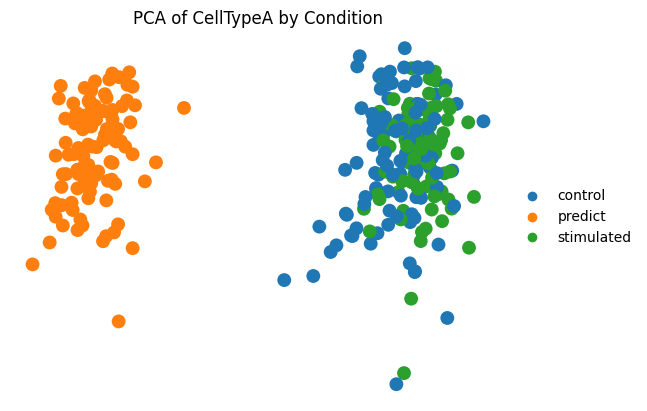

Compute rank_genes_groups...
Select common DEGS...
Common DEGs:  0
Regression plot of mean...


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


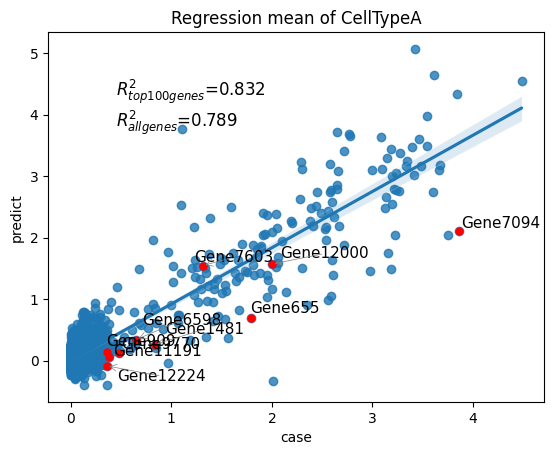

R2 mean of all genes 0.789, top genes 0.832
Regression plot of var...


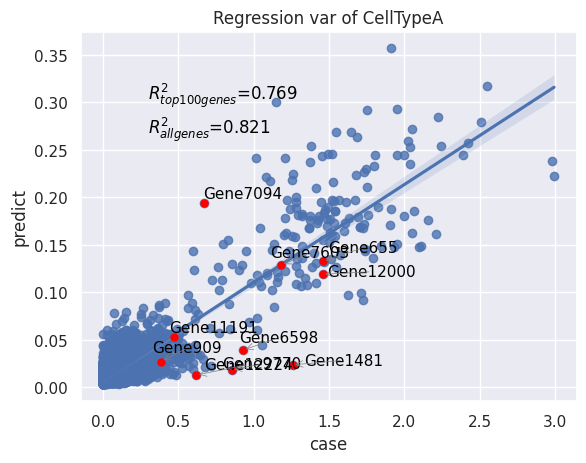

R2 var of all genes 0.821, top genes 0.769
Plot violin graph of first gene Gene7094...


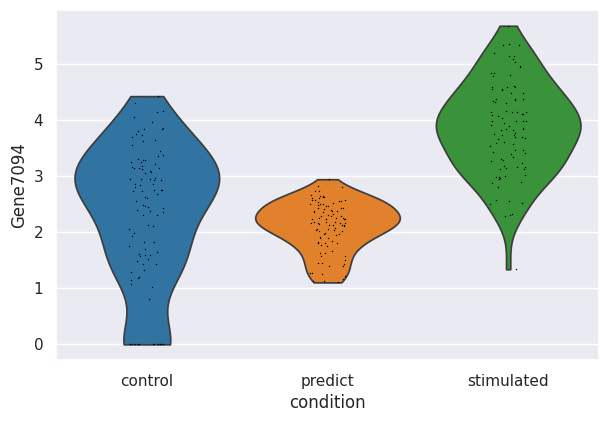

Plot violin graph of second gene Gene12000...


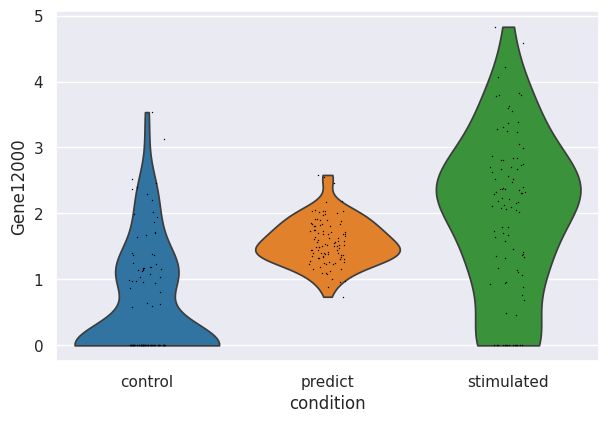

Plot violin graph of third gene Gene1481...


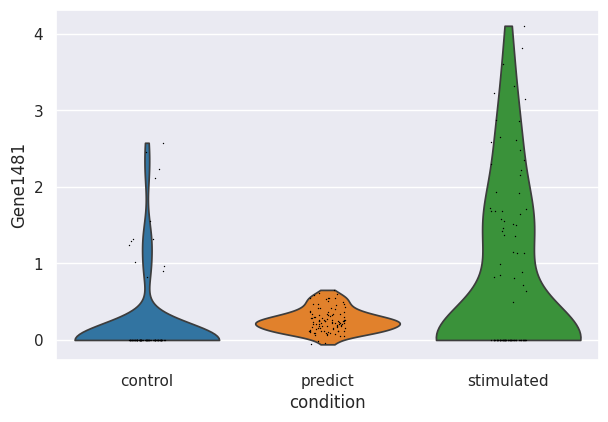

Compute DEGS contrast...
Plot 25 genes of eval_adata...


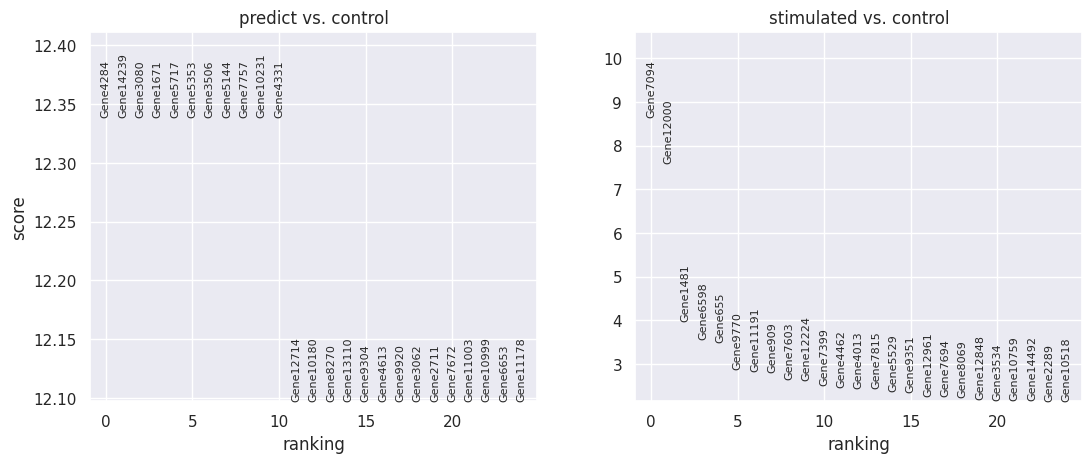

Dotplot of the first 20 genes...


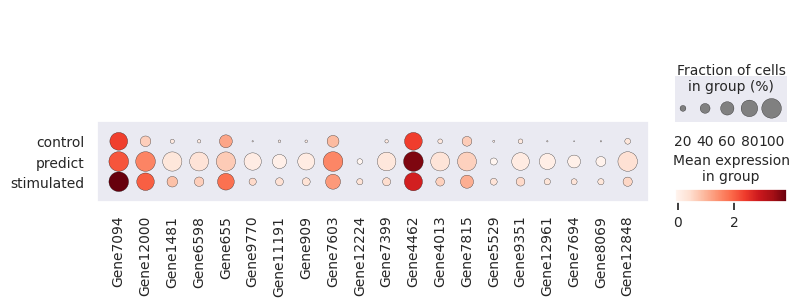

In [7]:
ground_truth = adata[(adata.obs[key_dic['cell_type_key']] == cell_to_pred)]
eval_adata = ground_truth.concatenate(pred)
scresid.evaluate(eval_adata=eval_adata, 
                cell_type=cell_to_pred, 
                key_dic=key_dic
                )